In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from qiskit.primitives import StatevectorSampler as Sampler

from qiskit_machine_learning.kernels import TrainableFidelityQuantumKernel
from qiskit_machine_learning.kernels import FidelityQuantumKernel
from qiskit_machine_learning.state_fidelities import ComputeUncompute
from qiskit_machine_learning.algorithms import PegasosQSVC
from sklearn.svm import SVC

from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
#import os
#os.environ["OMP_NUM_THREADS"] = "8"
N_QUBITS = 8
df_data = pd.read_csv('features_geometry_70.csv')

X = df_data.drop(columns=['class', 'image_name'])
feature_cols = [
    "dist_thumb_index",
    "dist_index_middle",
    "dist_middle_ring",
    "dist_ring_pinky",
    "angle_index",
    "angle_middle",
    "angle_ring",
    "angle_pinky",
]

X = df_data[feature_cols]

y = df_data['class']

#pca = PCA(n_components=N_QUBITS)
#X_pca= pca.fit_transform(X)  

print(X.shape)


scaler = MinMaxScaler(feature_range=(0, np.pi))
X_scaled = scaler.fit_transform(X)


le = LabelEncoder()
y_encoded = le.fit_transform(y)  

print(f"Classes: {le.classes_}")  

sss_train = StratifiedShuffleSplit(
    n_splits=1,
    train_size=0.05,
    random_state=42
)

idx_train, idx_unused = next(sss_train.split(X_scaled, y_encoded))

X_train = X_scaled[idx_train]
y_train = y_encoded[idx_train]





X_cv_raw = df_data[feature_cols].to_numpy()

le = LabelEncoder()
y_cv = le.fit_transform(df_data["class"].to_numpy())

print(f"Total: {X_cv_raw.shape}")
print(f"Classes: {le.classes_}")

(45014, 8)
Classes: ['A' 'B' 'C' 'D' 'E' 'F' 'G' 'I' 'L' 'M' 'N' 'O' 'P' 'Q' 'R' 'S' 'T' 'U'
 'V' 'W' 'Y']
Total: (45014, 8)
Classes: ['A' 'B' 'C' 'D' 'E' 'F' 'G' 'I' 'L' 'M' 'N' 'O' 'P' 'Q' 'R' 'S' 'T' 'U'
 'V' 'W' 'Y']


In [2]:
import json
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import clear_output
from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector
from qiskit.circuit.library import ZZFeatureMap, RealAmplitudes
from qiskit.quantum_info import SparsePauliOp
from qiskit.primitives import StatevectorEstimator as Estimator
from qiskit_machine_learning.optimizers import COBYLA, SPSA
from qiskit_machine_learning.utils import algorithm_globals
from qiskit_machine_learning.algorithms.classifiers import NeuralNetworkClassifier
from qiskit_machine_learning.neural_networks import EstimatorQNN, SamplerQNN
from sklearn.model_selection import train_test_split

algorithm_globals.random_seed = 12345
estimator = Estimator()

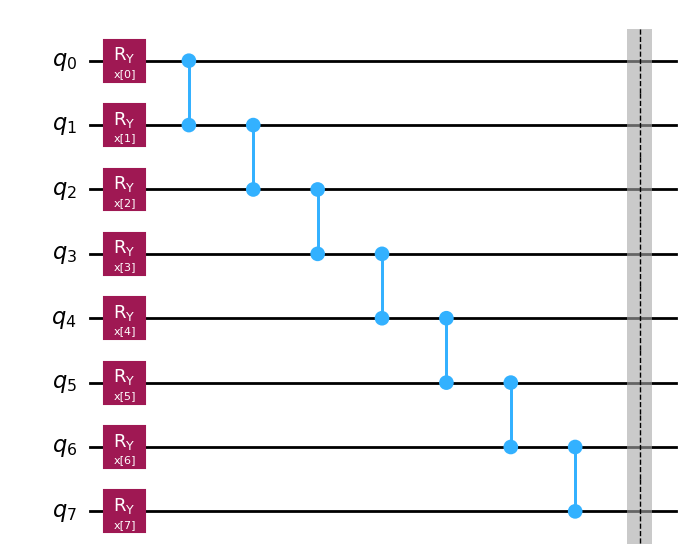

In [3]:
from math import ceil
from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector

num_features = 8
num_qubits = 8

data_vector = ParameterVector("x", num_features)

def build_data_reupload_only(num_qubits, num_features, data_vector):
    qc = QuantumCircuit(num_qubits)

    num_reuploads = ceil(num_features / num_qubits)
    feature_idx = 0

    for layer in range(num_reuploads):
        for q in range(num_qubits):
            if feature_idx < num_features:
                qc.ry(data_vector[feature_idx], q)
                feature_idx += 1

        for q in range(num_qubits - 1):
            qc.cz(q, q + 1)

        qc.barrier()

    return qc

reupload = build_data_reupload_only(
    num_qubits=num_qubits,
    num_features=num_features,
    data_vector=data_vector
)

reupload.draw("mpl")

In [4]:
from qiskit.circuit.library import RealAmplitudes
from qiskit import QuantumCircuit
from qiskit.circuit.library import ZZFeatureMap
import json
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import clear_output
from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector
from qiskit.circuit.library import ZZFeatureMap, RealAmplitudes
from qiskit.quantum_info import SparsePauliOp
from qiskit.primitives import StatevectorEstimator as Estimator
from qiskit_machine_learning.optimizers import COBYLA
from qiskit_machine_learning.utils import algorithm_globals
from qiskit_machine_learning.algorithms.classifiers import NeuralNetworkClassifier
from qiskit_machine_learning.neural_networks import EstimatorQNN, SamplerQNN
from sklearn.model_selection import train_test_split


num_features = 8       
print(f"Usando {num_features} qubits")



ansatz = RealAmplitudes(num_features, reps=1)

qc = QuantumCircuit(num_features)

# Primeira codificação dos dados
qc.compose(reupload, inplace=True)

# Ansatz fixo no meio
qc.compose(ansatz.decompose(), inplace=True)

# Segunda codificação dos dados
qc.compose(reupload, inplace=True)

rand_num_generator = np.random.RandomState(42)

theta_values = rand_num_generator.uniform(
    0,
    2 * np.pi,
    len(ansatz.parameters)
)

qc_fixed = qc.assign_parameters(
    dict(zip(ansatz.parameters, theta_values)),
    inplace=False
)

print(f"Parâmetros restantes no qc_fixed: {qc_fixed.num_parameters}")
print(qc_fixed.parameters)


Usando 8 qubits
Parâmetros restantes no qc_fixed: 8
ParameterView([ParameterVectorElement(x[0]), ParameterVectorElement(x[1]), ParameterVectorElement(x[2]), ParameterVectorElement(x[3]), ParameterVectorElement(x[4]), ParameterVectorElement(x[5]), ParameterVectorElement(x[6]), ParameterVectorElement(x[7])])


/var/folders/2_/jlrh0qwn1n3fq71vkp57s1jc0000gn/T/ipykernel_44634/1715909539.py:25: DeprecationWarning: The class ``qiskit.circuit.library.n_local.real_amplitudes.RealAmplitudes`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.real_amplitudes instead.
  ansatz = RealAmplitudes(num_features, reps=1)


In [5]:
from qiskit.primitives import StatevectorSampler as Sampler
from qiskit_machine_learning.kernels import FidelityQuantumKernel
from qiskit_machine_learning.state_fidelities import ComputeUncompute
from qiskit_machine_learning.kernels.algorithms import QuantumKernelTrainer




In [6]:
from sklearn.model_selection import StratifiedKFold, StratifiedShuffleSplit
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from qiskit_machine_learning.algorithms import QSVC

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import time

CV_N_SPLITS = 5
SEED = 42

# Se quiser usar todo o treino de cada fold, coloque None.
CV_TRAIN_FRACTION = 0.02
CV_TEST_FRACTION = 0.05

fold_metrics = []
all_y_true = []
all_y_pred = []

best_fold = None
best_f1 = -1
y_true_best = []
y_pred_best = []

skf = StratifiedKFold(
    n_splits=CV_N_SPLITS,
    shuffle=True,
    random_state=SEED
)


for fold_idx, (idx_train, idx_test) in enumerate(skf.split(X_cv_raw, y_cv), start=1):
    print(f"\n===== Fold {fold_idx}/{CV_N_SPLITS} =====")
    t0 = time.time()

    if CV_TRAIN_FRACTION is not None:
        sss_train = StratifiedShuffleSplit(
            n_splits=1,
            train_size=CV_TRAIN_FRACTION,
            random_state=SEED + fold_idx
        )

        idx_train_sub, _ = next(
            sss_train.split(X_cv_raw[idx_train], y_cv[idx_train])
        )

        idx_train_real = idx_train[idx_train_sub]
    else:
        idx_train_real = idx_train
    
    if CV_TEST_FRACTION is not None:
        idx_test, _ = train_test_split(
            idx_test,
            test_size=1 - CV_TEST_FRACTION,
            stratify=y_cv[idx_test],
            random_state=SEED + fold_idx,
        )


    scaler_fold = MinMaxScaler(feature_range=(0, np.pi))

    X_fold_train = scaler_fold.fit_transform(X_cv_raw[idx_train_real])
    X_fold_test = scaler_fold.transform(X_cv_raw[idx_test])

    y_fold_train = y_cv[idx_train_real]
    y_fold_test = y_cv[idx_test]

    print(f"Treino: {X_fold_train.shape} | Teste: {X_fold_test.shape}")

    sampler = Sampler()
    fidelity = ComputeUncompute(sampler=sampler)

    qkernel_fold = FidelityQuantumKernel(
    fidelity=fidelity,
    feature_map=qc_fixed
    )

    qsvc = QSVC(quantum_kernel=qkernel_fold, C=1000)
    qsvc.fit(X_fold_train, y_fold_train)

    y_pred_fold = qsvc.predict(X_fold_test)

    acc = accuracy_score(y_fold_test, y_pred_fold)
    f1 = f1_score(y_fold_test, y_pred_fold, average="macro", zero_division=0)
    elapsed = time.time() - t0

    print(f"Fold {fold_idx} | acc={acc:.4f} | f1={f1:.4f} | tempo={elapsed/60:.1f} min")

    fold_metrics.append({
        "fold": fold_idx,
        "test_acc": acc,
        "test_f1": f1,
        "elapsed_min": elapsed / 60,
        "n_train": len(X_fold_train),
        "n_test": len(X_fold_test)
    })


    all_y_true.extend(y_fold_test.tolist())
    all_y_pred.extend(y_pred_fold.tolist())

    if f1 > best_f1:
        best_f1 = f1
        best_fold = fold_idx
        y_true_best = y_fold_test.tolist()
        y_pred_best = y_pred_fold.tolist()


===== Fold 1/5 =====
Treino: (720, 8) | Teste: (450, 8)
Fold 1 | acc=0.9756 | f1=0.9756 | tempo=88.0 min

===== Fold 2/5 =====
Treino: (720, 8) | Teste: (450, 8)
Fold 2 | acc=0.9600 | f1=0.9598 | tempo=79.4 min

===== Fold 3/5 =====
Treino: (720, 8) | Teste: (450, 8)
Fold 3 | acc=0.9622 | f1=0.9627 | tempo=81.9 min

===== Fold 4/5 =====
Treino: (720, 8) | Teste: (450, 8)
Fold 4 | acc=0.9578 | f1=0.9579 | tempo=112.4 min

===== Fold 5/5 =====
Treino: (720, 8) | Teste: (450, 8)
Fold 5 | acc=0.9489 | f1=0.9481 | tempo=89.6 min


In [7]:
metrics_df = pd.DataFrame(fold_metrics).sort_values("fold")

print(metrics_df.to_string(index=False))

print(f"\nAccuracy: {metrics_df['test_acc'].mean():.4f} +/- {metrics_df['test_acc'].std(ddof=1):.4f}")
print(f"Macro F1: {metrics_df['test_f1'].mean():.4f} +/- {metrics_df['test_f1'].std(ddof=1):.4f}")

 fold  test_acc  test_f1  elapsed_min  n_train  n_test
    1  0.975556 0.975644    88.001395      720     450
    2  0.960000 0.959790    79.365678      720     450
    3  0.962222 0.962669    81.911763      720     450
    4  0.957778 0.957932   112.421970      720     450
    5  0.948889 0.948134    89.577892      720     450

Accuracy: 0.9609 +/- 0.0096
Macro F1: 0.9608 +/- 0.0099


In [8]:
print(classification_report(
    all_y_true,
    all_y_pred,
    target_names=le.classes_,
    digits=4,
    zero_division=0
))


              precision    recall  f1-score   support

           A     0.9151    0.9238    0.9194       105
           B     0.9402    1.0000    0.9692       110
           C     0.9432    1.0000    0.9708        83
           D     0.9474    0.9818    0.9643       110
           E     0.9640    0.9727    0.9683       110
           F     0.9604    0.9238    0.9417       105
           G     0.9813    0.9545    0.9677       110
           I     1.0000    1.0000    1.0000       110
           L     1.0000    0.9909    0.9954       110
           M     0.9550    0.9636    0.9593       110
           N     0.9810    0.9810    0.9810       105
           O     1.0000    0.9895    0.9947        95
           P     1.0000    0.9545    0.9767       110
           Q     1.0000    1.0000    1.0000       110
           R     0.9118    0.8455    0.8774       110
           S     0.9505    0.8727    0.9100       110
           T     0.9189    0.9533    0.9358       107
           U     0.8559    

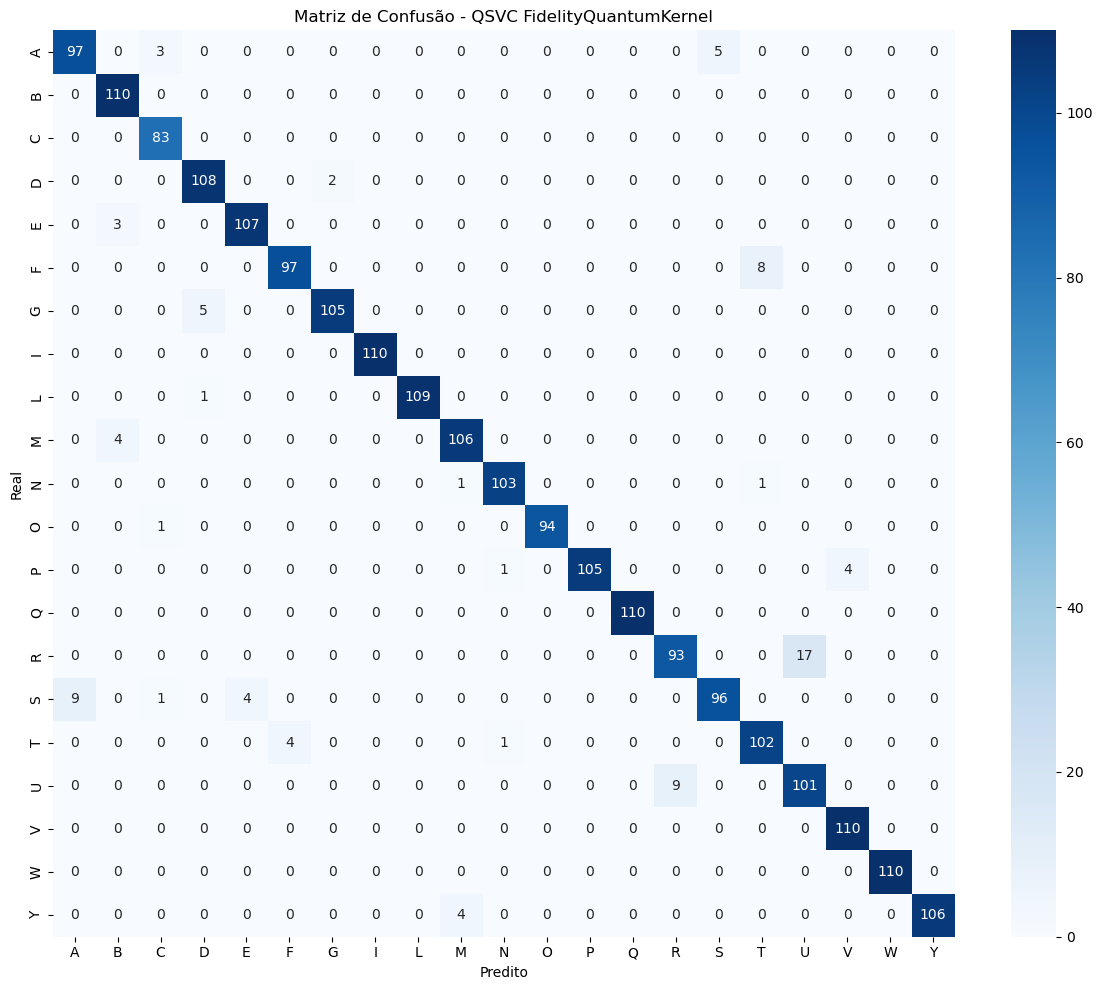

In [12]:
cm_best = confusion_matrix(all_y_true, all_y_pred)

plt.figure(figsize=(12, 10))
sns.heatmap(
    cm_best,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=le.classes_,
    yticklabels=le.classes_
)
plt.xlabel("Predito")
plt.ylabel("Real")
plt.title(f"Matriz de Confusão - QSVC FidelityQuantumKernel")
plt.tight_layout()
plt.show()